In [1]:
import os
import sys
import argparse

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

writer = SummaryWriter(log_dir=f"runs/genrkm_{ct}")

In [5]:
def kPCA(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def rkm_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)
    U = torch.mm(output1.t(), h)
    V = torch.mm(output2.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))
    y_logits = net4(torch.mm(h, V.t()))   # treat as logits (no softmax here)

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t())) + torch.trace(
         torch.mm(torch.mm(output2, V), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * (torch.trace(torch.mm(U.t(), U)) + torch.trace(torch.mm(V.t(), V)))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    # Label loss: supports Y as one-hot (B,10) or indices (B,)
    if Y.dim() == 2 and Y.size(-1) == 10:
        y_idx = Y.argmax(dim=1).long()
    else:
        y_idx = Y.long().view(-1)

    ce = torch.nn.CrossEntropyLoss()
    lbl_loss = ce(y_logits.view(-1, 10), y_idx)

    f4 = img_loss + lbl_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [7]:
net1 = Net1(opt).double().to(opt.device)
net2 = Net2(opt).double().to(opt.device)
net3 = Net3(opt).double().to(opt.device)
net4 = Net4(opt).double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)
loss_history = []

In [9]:
l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost
start = datetime.now()
global_step = 0

while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    avg_loss = 0
    for i, (datax, datay) in enumerate(xtrain):
        if i < math.ceil(opt.N / opt.mb_size):
            datax, datay = datax.to(opt.device), datay.to(opt.device)
            output1 = net1(datax)
            output2 = net2(datay)

            loss = rkm_loss(output1, datax, output2, datay)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            writer.add_scalar("Loss/train_batch", loss.item(), global_step)
            global_step += 1
            avg_loss += loss.detach().cpu().numpy()
        else:
            break
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)

    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'net2_state_dict': net2.state_dict(),
        'net4_state_dict': net4.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)
    print(t, cost)
    t += 1
    loss_history.append(cost)
    writer.add_scalar("Loss/train_epoch", cost, t)
print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

Finished Training in: 0:00:00.000160. Lowest cost: 6


In [10]:
# plt.plot(loss_history)
# plt.xlabel('Epochs')
# plt.ylabel('Cost')
# plt.title('Training Loss over Epochs')
# plt.grid()
# plt.show()

In [11]:
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net1.load_state_dict(sd_mdl['net1_state_dict'])
#     net3.load_state_dict(sd_mdl['net3_state_dict'])
#     net2.load_state_dict(sd_mdl['net2_state_dict'])
#     net4.load_state_dict(sd_mdl['net4_state_dict'])

# U, V, h, s = final_compute(opt, net1, net2, kPCA)

In [12]:
# torch.save({'net1': net1,
#             'net3': net3,
#             'net2': net2,
#             'net4': net4,

#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),
#             'net2_state_dict': net2.state_dict(),
#             'net4_state_dict': net4.state_dict(),

#             'datax': datax,
#             'datay': datay,

#             'h': h,
#             'opt': opt, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

In [13]:
model = torch.load('out/Final.tar', weights_only=False)

U = model['U']
V = model['V']
h = model['h']
s = model['s']

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

datax = model['datax']
datay = model['datay']

## Evaluation

In [14]:
recon_loss = torch.nn.MSELoss(reduction='mean')

net1.eval()
net2.eval()
net3.eval()
net4.eval()

digit_loss_sum = 0.
label_loss_sum = 0.
loss_sum = 0.
n = 0

out_data_x_test, out_data_y_test = [], []
in_data_x_test, in_data_y_test = [], []

with torch.no_grad():
    for i, (datax, datay) in enumerate(xtest):
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)

        in_data_x_test.append(datax.cpu().numpy())
        in_data_y_test.append(datay.cpu().numpy())

        x_en = net1(datax)
        y_en = net2(datay)

        _h, _ = kPCA(x_en, y_en)

        U = torch.mm(torch.t(x_en), _h)
        V = torch.mm(torch.t(y_en), _h)

        x_tilde = net3(torch.mm(_h, torch.t(U)))
        y_tilde = net4(torch.mm(_h, torch.t(V)))

        out_data_x_test.append(x_tilde.cpu().numpy())
        out_data_y_test.append(y_tilde.cpu().numpy())

        B = datax.size(0)

        digit_loss = recon_loss(x_tilde.view(B, -1), datax.view(B, -1))
        label_loss = 1 - oh_binary_accuracy(datay.cpu().numpy(), y_tilde.view(B, -1).cpu().numpy())

        digit_loss_sum += digit_loss.item() * B
        label_loss_sum += label_loss.item() * B

        loss_sum += (digit_loss + label_loss).item() / 2 * B
        n += B

digit_loss = digit_loss_sum / n
label_loss = label_loss_sum / n
total_loss = loss_sum / n

print("Total Loss:", total_loss)
print("Digit Reconstruction Loss:", digit_loss)
print("Label Loss:", label_loss)

Total Loss: 0.006013469713507001
Digit Reconstruction Loss: 0.011526939427014002
Label Loss: 0.0005


## Visual Inspection

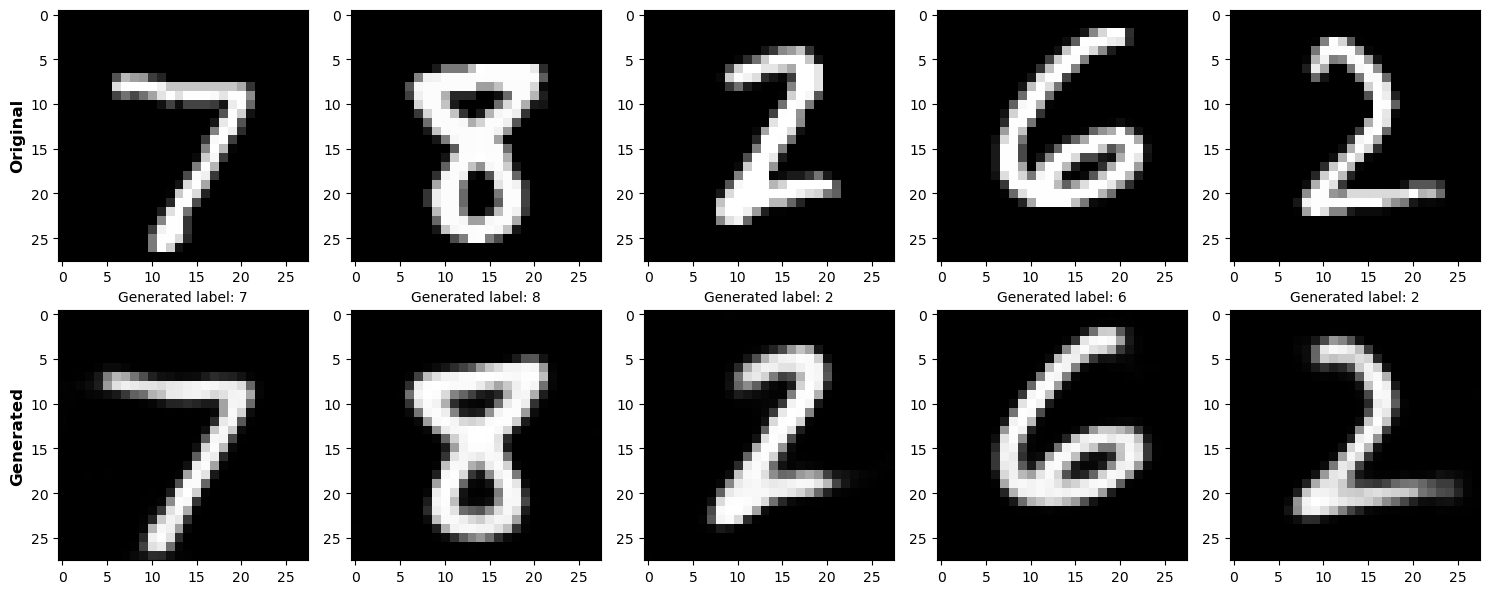

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx in range(5):    
    axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Generated', fontsize=12, fontweight='bold')

    axes[0, idx].imshow(in_data_x_test[idx][0].reshape(28, 28), cmap='gray')

    axes[1, idx].imshow(out_data_x_test[idx][0].reshape(28, 28), cmap='gray')
    axes[1, idx].set_title('Generated label: {}'.format(out_data_y_test[idx][0].argmax()), fontsize=10)


plt.tight_layout()
plt.show()

## Disentanglement

In [16]:
Zs = []

with torch.no_grad():
    for datax, datay in xtrain:
        datay = datay.to(opt.device)
        
        Zs.append(datay.cpu().numpy())

C = h.detach().cpu().numpy()
Z = np.concatenate(Zs, axis=0)[:10000]

factor_types = ["discrete"] * Z.shape[1]

In [17]:
C.shape, Z.shape

((10000, 24), (10000, 10))

In [18]:
res = compute_dci(C, Z, factor_types, probe="lasso")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.113
 > Completeness: 0.0959
 > Informativeness: 0.9


- Low D & C -> Did not to learn to store digits based on value, it **organized its latent space around other factors**
- High I -> The representation did store the digits wellI men

-> Other scores must be used

## IRS

In [19]:
irs_results = compute_irs(C, Z)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.4078


### MIG

In [20]:
mig_res = compute_mig(C, Z)
print(f'--- MIG Scores ---')
print(f' > MIG: {round(mig_res["MIG"], 4)}')

--- MIG Scores ---
 > MIG: 0.0008
